# LSTM Model for Stock Prediction

## Why LSTM?

Traditional machine learning models treat every row independently.

However, financial markets are sequential systems where past movements influence future behavior.

Long Short-Term Memory (LSTM) networks are designed to learn patterns from sequences of historical observations.

---

## Objective

Train an LSTM network to predict whether Apple's next trading day will close higher or lower.

We compare its performance against:

- Logistic Regression
- Random Forest
- XGBoost

---

## Key Difference

Classical models:

- Use individual rows.

LSTM:

- Uses sequences of multiple days.

For this project, we use windows of 30 trading days.

In [2]:
# imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

In [3]:
# load dataset
df = pd.read_csv(
    "../data/btc_model_data.csv",
    parse_dates=["Date"]
)
df.head()

,Date,Close,High,Low,Open,Volume,Change,Return,Volume_Change,Momentum_5,MA_10,MA_50,Volatility,RSI,MACD,MACD_Signal,MACD_Hist,Target
0,2020-03-13,67.102943,67.573683,61.063026,63.945388,370732000,3.157555,0.119809,-0.114086,-2.669914,68.219660,73.733391,0.055299,45.241617,-2.642674,-2.022544,-0.620129,0
1,2020-03-16,58.470356,62.542829,57.936853,58.407589,322423600,0.062767,-0.128647,-0.130305,-5.784023,66.853317,73.456120,0.061639,36.847060,-3.202935,-2.258622,-0.944312,1
2,2020-03-17,61.041290,62.187953,57.550594,59.749780,324056000,1.291510,0.043970,0.005063,-7.840782,65.973162,73.244333,0.062905,40.394235,-3.400296,-2.486957,-0.913339,0
3,2020-03-18,59.547001,60.350875,57.241597,57.881318,300233600,1.665683,-0.024480,-0.073513,-6.942753,64.619614,72.991245,0.062721,39.022310,-3.635377,-2.716641,-0.918736,0
4,2020-03-19,59.090748,61.036459,58.566903,59.720811,271857200,-0.630063,-0.007662,-0.094514,-0.832832,63.457498,72.735823,0.062726,38.591330,-3.814524,-2.936218,-0.878306,0


In [4]:
features = [
    "Close",
    "Volume",
    "RSI",
    "MACD",
    "Volatility"
]

X = df[features]

y = df["Target"]

# Feature Scaling

Neural networks train more efficiently when features are normalized.

We use Min-Max scaling to map all features into the range [0, 1].

In [5]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(X)

# Sequence Construction

Instead of treating each row independently, we create windows of 30 consecutive trading days.

Example:

Input:

Days 1–30

Output:

Direction on Day 31

In [6]:
sequence_length = 30

X_sequences = []
y_sequences = []

for i in range(sequence_length, len(scaled_data)):

    X_sequences.append(
        scaled_data[
            i-sequence_length:i
        ]
    )

    y_sequences.append(
        y.iloc[i]
    )

X_sequences = np.array(
    X_sequences
)

y_sequences = np.array(
    y_sequences
)

In [7]:
print(X_sequences.shape)
print(y_sequences.shape)

(1179, 30, 5)
(1179,)


In [8]:
# train test split
split = int(
    len(X_sequences) * 0.8
)

X_train = X_sequences[:split]
X_test = X_sequences[split:]

y_train = y_sequences[:split]
y_test = y_sequences[split:]

# LSTM Architecture

The network consists of:

- One LSTM layer.
- Dropout for regularization.
- Dense output layer.

The output neuron predicts the probability of an upward movement.

In [9]:
model = Sequential([
    LSTM(
        64,
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    ),

    Dropout(0.2),

    Dense(
        1,
        activation="sigmoid"
    )
])

c:\Users\Dhruvil\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
# complie 
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [11]:
# train
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.4811 - loss: 0.6976 - val_accuracy: 0.5263 - val_loss: 0.6927
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5307 - loss: 0.6960 - val_accuracy: 0.5263 - val_loss: 0.6926
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5354 - loss: 0.6920 - val_accuracy: 0.5263 - val_loss: 0.6922
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5342 - loss: 0.6929 - val_accuracy: 0.4947 - val_loss: 0.6924
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5236 - loss: 0.6916 - val_accuracy: 0.5263 - val_loss: 0.6918
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5366 - loss: 0.6929 - val_accuracy: 0.5579 - val_loss: 0.6918
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5236 - loss: 0.6908 - val_accuracy: 0.5263 - val_loss: 0.6918
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5295 - loss: 0.6921 - val_accuracy: 0.5263 - v

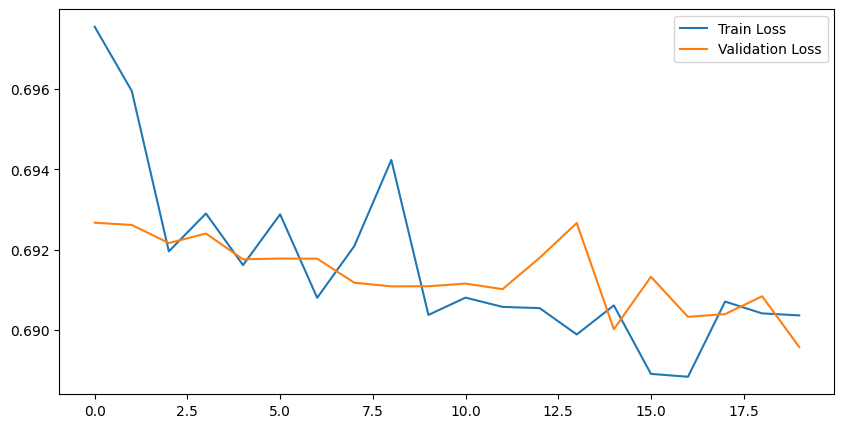

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.legend()

plt.show()

In [14]:
# prediction
probabilities = model.predict(
    X_test
)

predictions = (
    probabilities > 0.5
).astype(int)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


In [15]:
# metrics
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        predictions
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        predictions
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        predictions
    )
)

Accuracy: 0.4576271186440678
Precision: 0.5346534653465347
Recall: 0.4


In [17]:
model.save("../models/lstm_model.keras")